In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data, filter_data
from grb.const import TRIGGER_TIME
from grb.analysis import Analyzer

from grb.functions import *
from grb.prior import *
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve

In [3]:
from grb.const import REDSHIFT
print(REDSHIFT)

0.572


## 7DT SED fit

In [ ]:
df_sdt = read_data("sdt", correct_galactic_extinction=True, add_converted_flux=True)

eta = host_galaxy_extinction_curve(df_sdt["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=1e15) * host_galaxy_extinction(x, *params[2:], eta=eta)
    
param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed = Analyzer(df_sdt["frequency_Hz"], df_sdt["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt["flux_error_mJy"], x_data_error=df_sdt["frequency_error_Hz"], param_bounds=param_bounds, prior=prior)
alz_sed.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5e+01   [-52.1684..-52.1684]*| it/evals=4239/107423 eff=3.9571% N=300      00 0 0 0 
[ultranest] Likelihood function evaluations: 107423
[ultranest]   logZ = -61.67 +- 0.1337
[ultranest] Effective samples strategy satisfied (ESS = 1212.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.17 bs:0.13 tail:0.01 total:0.13 required:<0.50
[ultranest] done iterating.


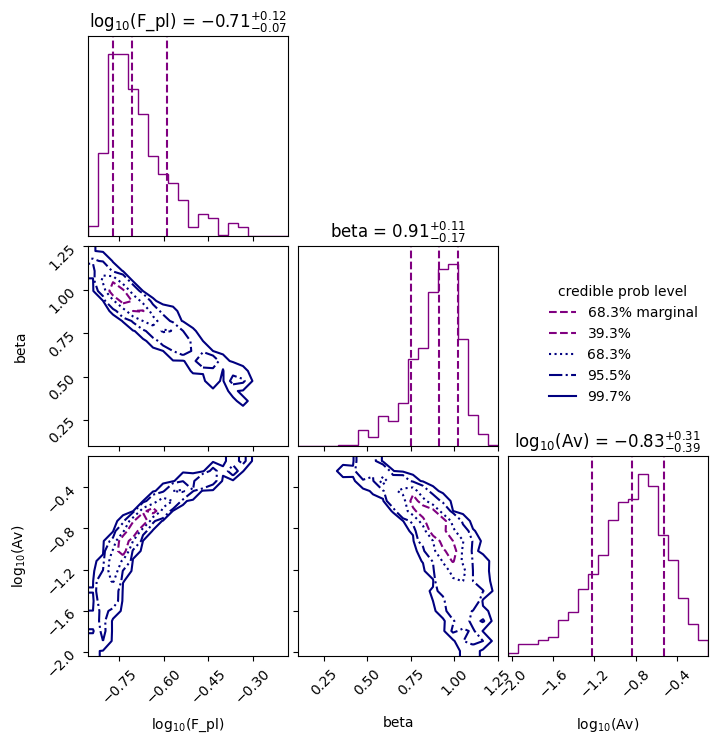

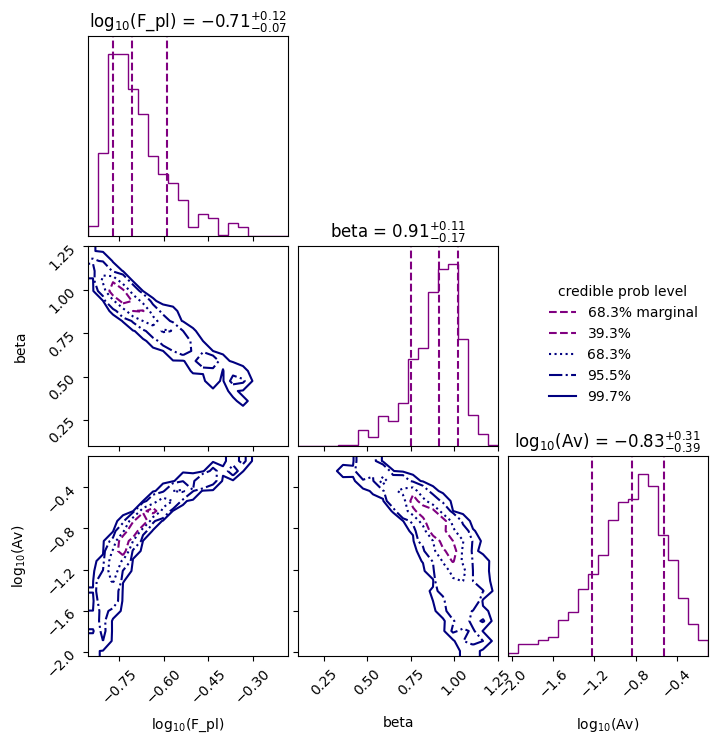

In [5]:
alz_sed.plot_corner()

<Axes: xlabel='Frequency', ylabel='Flux'>

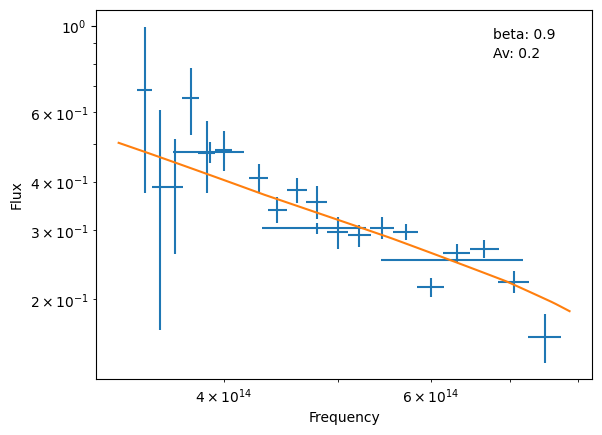

In [6]:
alz_sed.plot_data()
alz_sed.plot_model(show_param=True)


In [7]:
alz_sed.results

{'niter': 4540,
 'logz': -61.68130298250831,
 'logzerr': 0.2946749764584175,
 'logz_bs': -61.672878103169786,
 'logz_single': -61.68130298250831,
 'logzerr_tail': 0.009927155895560702,
 'logzerr_bs': 0.2945077135264782,
 'ess': 1212.0804046602336,
 'H': 8.442049240704883,
 'Herr': 0.12333147494189972,
 'posterior': {'mean': [0.21379016824720745,
   0.8900890709553545,
   0.18272998456737607],
  'stdev': [0.05795282963888171, 0.14046288907979568, 0.13504608638998214],
  'median': [0.19671931023189362, 0.9142238013084591, 0.1490784442124487],
  'errlo': [0.16898833298901075, 0.7485773841215313, 0.06038055676279233],
  'errup': [0.25912207363371126, 1.020545245140301, 0.3014784009073528],
  'information_gain_bits': [3.017725763120161,
   1.357347396143746,
   -4.788414964756674]},
 'weighted_samples': {'upoints': array([[0.98688462, 0.77441936, 0.27841826],
         [0.94546152, 0.96347579, 0.31836188],
         [0.99651778, 0.54123896, 0.00328511],
         ...,
         [0.26199643, 0.3

## 7DT tractor SED

In [29]:
df_sdt_tractor = read_data("sdt_tractor", correct_galactic_extinction=True, add_converted_flux=True)
eta = host_galaxy_extinction_curve(df_sdt_tractor["frequency_Hz"])
combined_func = lambda x, *params: power_law(x, *params[:2], x0=1e15) * host_galaxy_extinction(x, *params[2:], eta=eta)

param_bounds, prior = power_law_prior(data_type="sed")
param_bounds_ext, prior_ext = host_galaxy_extinction_prior()
param_bounds.update(param_bounds_ext)
prior.update(prior_ext)

alz_sed_tractor = Analyzer(df_sdt_tractor["frequency_Hz"], df_sdt_tractor["flux_mJy"], combined_func, data_type="sed", y_data_error=df_sdt_tractor["flux_error_mJy"], x_data_error=df_sdt_tractor["frequency_error_Hz"], param_bounds=param_bounds, prior=prior)
alz_sed_tractor.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+02  .33 [-654.7387..-654.7380]*| it/evals=5748/130703 eff=4.4079% N=300   0  00 0 0 0 
[ultranest] Likelihood function evaluations: 130703
[ultranest]   logZ = -669.2 +- 0.1255
[ultranest] Effective samples strategy satisfied (ESS = 1675.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.20 bs:0.13 tail:0.01 total:0.13 required:<0.50
[ultranest] done iterating.


<Axes: xlabel='Frequency', ylabel='Flux'>

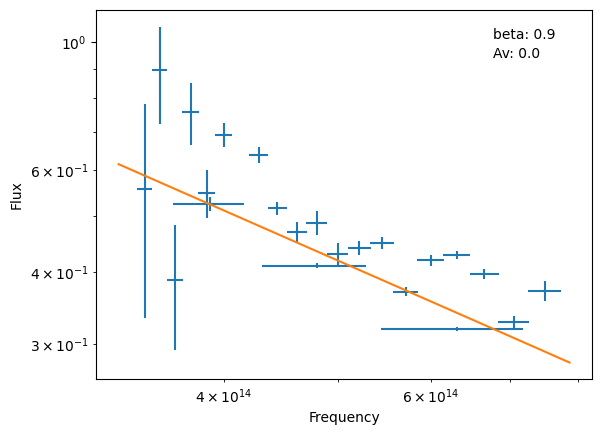

In [30]:
alz_sed_tractor.plot_data()
alz_sed_tractor.plot_model(show_param=True)

In [31]:
alz_sed_tractor.results

{'niter': 6049,
 'logz': -669.1817693242366,
 'logzerr': 0.17836338330068854,
 'logz_bs': -669.2065774192881,
 'logz_single': -669.1817693242366,
 'logzerr_tail': 0.009944276028818422,
 'logzerr_bs': 0.17808595642759428,
 'ess': 1675.2702699913277,
 'H': 12.24979443476775,
 'Herr': 0.11632476853351296,
 'posterior': {'mean': [0.23950183448905968,
   0.8554408635527053,
   0.03366715566312285],
  'stdev': [0.008525501674721044, 0.027276777684995302, 0.019247637461349613],
  'median': [0.2381487892714178, 0.8567474607734982, 0.030257320429086132],
  'errlo': [0.2316414495662824, 0.8297426416562876, 0.01572731293597294],
  'errup': [0.2473333340950531, 0.8814899752053915, 0.05231658978071357],
  'information_gain_bits': [3.8857501100440937,
   3.4122271204136547,
   0.13800682082533489]},
 'weighted_samples': {'upoints': array([[9.62945515e-01, 8.71116950e-01, 5.32838729e-01],
         [9.34613815e-01, 9.87333989e-01, 4.79127352e-01],
         [9.39569672e-01, 9.55897827e-01, 5.98493864e-

In [32]:
import pickle
import pandas as pd

sed_results = {
    "best_fit_params": alz_sed.best_fit_params,
    "param_names": alz_sed.params,
    "weighted_samples": alz_sed.results["weighted_samples"],
    "x_data": alz_sed.x_data,
    "y_data": alz_sed.y_data,
    "x_data_error": alz_sed.x_data_error,
    "y_data_error": alz_sed.y_data_error,
    "sdt_epoch_s": (pd.to_datetime(df_sdt["date_obs"]).mean() - TRIGGER_TIME).total_seconds(),
}

# Use df_sdt epoch for tractor too (same observation, tractor data lacks date_obs)
sdt_epoch_s = (pd.to_datetime(df_sdt["date_obs"]).mean() - TRIGGER_TIME).total_seconds()

sed_results_tractor = {
    "best_fit_params": alz_sed_tractor.best_fit_params,
    "param_names": alz_sed_tractor.params,
    "weighted_samples": alz_sed_tractor.results["weighted_samples"],
    "x_data": alz_sed_tractor.x_data,
    "y_data": alz_sed_tractor.y_data,
    "x_data_error": alz_sed_tractor.x_data_error,
    "y_data_error": alz_sed_tractor.y_data_error,
    "sdt_epoch_s": sdt_epoch_s,
}

with open("data/sed_fit_results.pkl", "wb") as f:
    pickle.dump(sed_results, f)

with open("data/sed_fit_results_tractor.pkl", "wb") as f:
    pickle.dump(sed_results_tractor, f)

print(f"Saved SED fit results to data/sed_fit_results.pkl")
print(f"Saved SED fit results to data/sed_fit_results_tractor.pkl")
print(f"Best-fit params: {dict(zip(sed_results['param_names'], sed_results['best_fit_params']))}")
print(f"Best-fit params (tractor): {dict(zip(sed_results_tractor['param_names'], sed_results_tractor['best_fit_params']))}")
print(f"SDT epoch: {sdt_epoch_s:.0f} s ({sdt_epoch_s/3600:.1f} hr)")

Saved SED fit results to data/sed_fit_results.pkl
Saved SED fit results to data/sed_fit_results_tractor.pkl
Best-fit params: {'F_pl': 0.20421299273049362, 'beta': 0.9009316741342824, 'Av': 0.1734931441504383}
Best-fit params (tractor): {'F_pl': 0.22605061849426203, 'beta': 0.892814510881968, 'Av': 0.0020354521778952212}
SDT epoch: 23287 s (6.5 hr)


## XRT

In [11]:
df_xrt = read_data("xrt")
df_filtered = filter_data(df_xrt, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df_filtered["Flux_high"], df_filtered["Flux_low"])])
alz_xrt = Analyzer(df_filtered["Time"][5:]/3600, df_filtered["Flux"][5:], broken_power_law, y_data_error=y_err[5:])
alz_xrt.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-1e+01   [-13.4076..-13.4067]*| it/evals=6111/214420 eff=2.8540% N=300   0 0 0 
[ultranest] Likelihood function evaluations: 214503
[ultranest]   logZ = -29.13 +- 0.1717
[ultranest] Effective samples strategy satisfied (ESS = 2336.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.


In [12]:
import os
import pickle

xrt_result = {
    "results": alz_xrt.results,
    "best_fit_params": alz_xrt.best_fit_params,
    "params": alz_xrt.params,
    "x_data": alz_xrt.x_data,
    "y_data": alz_xrt.y_data,
    "y_data_error": alz_xrt.y_data_error,
    "x_data_error": getattr(alz_xrt, "x_data_error", None),
    "data_type": "lightcurve",
}
print(f"XRT: params={alz_xrt.params}, best_fit={alz_xrt.best_fit_params}")

output_path = os.path.join(os.getcwd(), "xrt_fit_results.pkl")
with open(output_path, "wb") as f:
    pickle.dump({"xrt": xrt_result}, f)

print(f"\nXRT result saved to {output_path}")

XRT: params=['F_bpl', 't_break', 'alpha_1', 'alpha_2'], best_fit=[4.783880673688135e-11, 0.31669674870583386, 1.5736915047191875, 1.0040848257316746]

XRT result saved to /data9/hongyp/GRB251013C/GRB_fitting_test/xrt_fit_results.pkl


## Extrapolation to XRT (0.3–10 keV)

Loaded SED fit: {'F_pl': 0.20421299273049362, 'beta': 0.9009316741342824, 'Av': 0.1734931441504383}
Extrapolated F_ν at 1 keV: 1.4546e-03 mJy = 1.4546e-29 erg/cm²/s/Hz
Extrapolated 0.3–10 keV integrated flux: 1.3089e-11 erg/cm²/s
F_ν(1 keV) median: 1.1355e-03 mJy, 5σ range: [2.0118e-04, 3.5746e-02] mJy


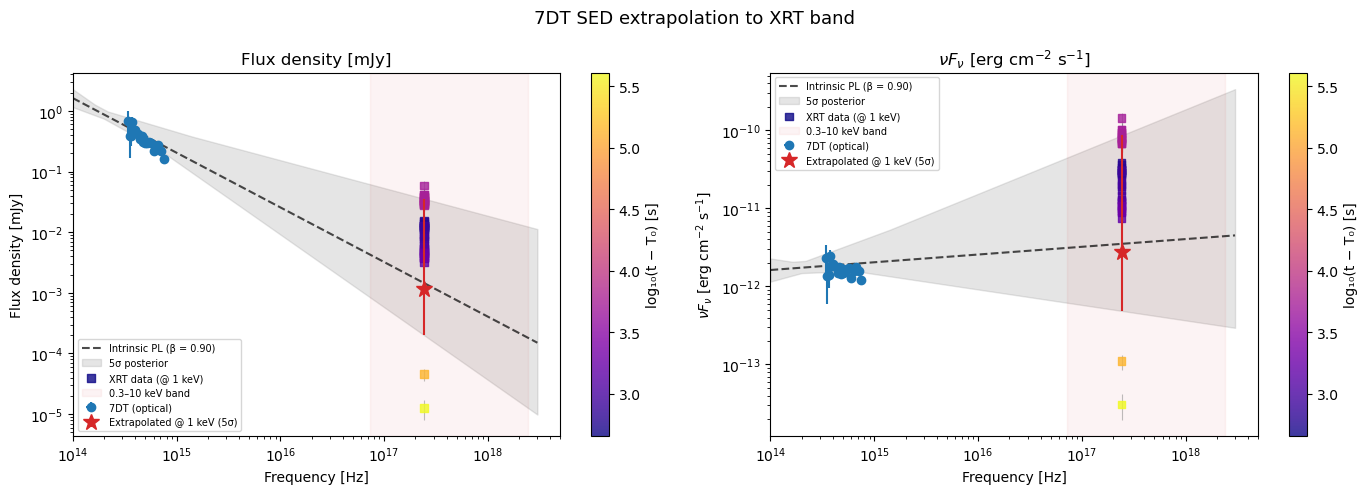

In [10]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from grb.functions import power_law
from grb.extinction import host_galaxy_extinction, host_galaxy_extinction_curve
from grb.io import read_data
from grb.const import TRIGGER_TIME

# --- Load SED fit results ---
with open("data/sed_fit_results.pkl", "rb") as f:
    sed = pickle.load(f)

best_params = sed["best_fit_params"]
param_names = sed["param_names"]
F0, beta_opt, Av = best_params[0], best_params[1], best_params[2]
print(f"Loaded SED fit: {dict(zip(param_names, best_params))}")

# --- XRT band frequencies ---
h_keV_s = 4.135667696e-18  # Planck constant [keV·s]
E_lo, E_hi, E_ref = 0.3, 10.0, 1.0  # keV
nu_xrt_lo = E_lo / h_keV_s
nu_xrt_hi = E_hi / h_keV_s
nu_1keV = E_ref / h_keV_s  # ~2.42e17 Hz

mJy_to_cgs = 1e-26  # mJy → erg/cm²/s/Hz

# --- Extrapolated flux density at 1 keV ---
F_nu_1keV_mJy = power_law(nu_1keV, F0, beta_opt, x0=1e15)
print(f"Extrapolated F_ν at 1 keV: {F_nu_1keV_mJy:.4e} mJy = {F_nu_1keV_mJy * mJy_to_cgs:.4e} erg/cm²/s/Hz")

if abs(beta_opt - 1.0) > 1e-10:
    int_flux_mJy_Hz = F0 * (1e15)**beta_opt * (nu_xrt_hi**(1-beta_opt) - nu_xrt_lo**(1-beta_opt)) / (1 - beta_opt)
else:
    int_flux_mJy_Hz = F0 * np.log(nu_xrt_hi / nu_xrt_lo)
int_flux_cgs = int_flux_mJy_Hz * mJy_to_cgs
print(f"Extrapolated 0.3–10 keV integrated flux: {int_flux_cgs:.4e} erg/cm²/s")

# --- Posterior uncertainty ---
samples = sed["weighted_samples"]["points"]
weights = sed["weighted_samples"]["weights"]

nu_extrap = np.geomspace(1e14, 3e18, 500)
idx = np.random.choice(len(samples), size=200, p=weights / weights.sum())
flux_samples_mJy = np.array([power_law(nu_extrap, s[0], s[1], x0=1e15) for s in samples[idx]])
flux_lo_mJy, flux_hi_mJy = np.percentile(flux_samples_mJy, [2.87e-5, 99.99997], axis=0)

F_1keV_samples = np.array([power_law(nu_1keV, s[0], s[1], x0=1e15) for s in samples[idx]])
F_1keV_lo, F_1keV_median, F_1keV_hi = np.percentile(F_1keV_samples, [2.87e-5, 50, 99.99997])
print(f"F_ν(1 keV) median: {F_1keV_median:.4e} mJy, 5σ range: [{F_1keV_lo:.4e}, {F_1keV_hi:.4e}] mJy")

flux_extrap_mJy = power_law(nu_extrap, F0, beta_opt, x0=1e15)

# --- Load XRT data and convert integrated flux → F_ν at 1 keV ---
# F_int = F_ν(ν_0) * ν_0^β * (ν_hi^{1-β} - ν_lo^{1-β}) / (1-β)
# → F_ν(ν_0) [erg/cm²/s/Hz] = F_int * (1-β) / (ν_0^β * (ν_hi^{1-β} - ν_lo^{1-β}))
df_xrt = read_data("xrt")
xrt_epoch_s = df_xrt["Time"].values  # seconds after trigger

def fint_to_fnu_mJy(F_int, beta, nu_0, nu_lo, nu_hi):
    if abs(beta - 1.0) > 1e-10:
        factor = (1 - beta) / (nu_0**beta * (nu_hi**(1-beta) - nu_lo**(1-beta)))
    else:
        factor = 1.0 / (nu_0 * np.log(nu_hi / nu_lo))
    return F_int * factor / mJy_to_cgs  # erg/cm²/s → mJy

xrt_fnu   = fint_to_fnu_mJy(df_xrt["Flux"].values,              beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)
xrt_fnu_hi = fint_to_fnu_mJy(df_xrt["Flux_high"].values,        beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)
xrt_fnu_lo = fint_to_fnu_mJy(np.abs(df_xrt["Flux_low"].values), beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)

# Color-code XRT points by epoch
norm = plt.Normalize(np.log10(xrt_epoch_s.min()), np.log10(xrt_epoch_s.max()))
cmap = plt.cm.plasma

# --- Plot 1: mJy scale ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 7DT data
ax1.errorbar(sed["x_data"], sed["y_data"], yerr=sed["y_data_error"], xerr=sed["x_data_error"],
             ls="", marker="o", color="C0", zorder=5, label="7DT (optical)")
ax1.plot(nu_extrap, flux_extrap_mJy, "k--", alpha=0.7, label=f"Intrinsic PL (β = {beta_opt:.2f})")
ax1.fill_between(nu_extrap, flux_lo_mJy, flux_hi_mJy, color="gray", alpha=0.2, label="5σ posterior")
ax1.errorbar(nu_1keV, F_1keV_median, yerr=[[F_1keV_median - F_1keV_lo], [F_1keV_hi - F_1keV_median]],
             fmt="*", color="C3", ms=12, zorder=6, label="Extrapolated @ 1 keV (5σ)")
# XRT data points at ν = 1 keV
sc1 = ax1.scatter([nu_1keV]*len(xrt_fnu), xrt_fnu,
                  c=np.log10(xrt_epoch_s), cmap=cmap, norm=norm,
                  s=30, zorder=5, marker="s", alpha=0.8, label="XRT data (@ 1 keV)")
ax1.errorbar([nu_1keV]*len(xrt_fnu), xrt_fnu,
             yerr=[xrt_fnu_lo, xrt_fnu_hi],
             fmt="none", ecolor="gray", elinewidth=0.8, alpha=0.5, zorder=4)
ax1.axvspan(nu_xrt_lo, nu_xrt_hi, alpha=0.05, color="C3", label="0.3–10 keV band")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("Frequency [Hz]"); ax1.set_ylabel("Flux density [mJy]")
ax1.set_title("Flux density [mJy]")
ax1.legend(fontsize=7); ax1.set_xlim(1e14, 5e18)
plt.colorbar(sc1, ax=ax1, label="log₁₀(t − T₀) [s]")

# --- Plot 2: νF_ν scale ---
nuFnu_extrap = nu_extrap * flux_extrap_mJy * mJy_to_cgs
nuFnu_lo     = nu_extrap * flux_lo_mJy * mJy_to_cgs
nuFnu_hi     = nu_extrap * flux_hi_mJy * mJy_to_cgs

nuFnu_data     = sed["x_data"] * sed["y_data"] * mJy_to_cgs
nuFnu_data_err = sed["x_data"] * sed["y_data_error"] * mJy_to_cgs
nuFnu_data_xerr = sed["x_data_error"]

nuFnu_1keV_median = nu_1keV * F_1keV_median * mJy_to_cgs
nuFnu_1keV_lo     = nu_1keV * F_1keV_lo * mJy_to_cgs
nuFnu_1keV_hi     = nu_1keV * F_1keV_hi * mJy_to_cgs

nuFnu_xrt     = nu_1keV * xrt_fnu    * mJy_to_cgs
nuFnu_xrt_hi  = nu_1keV * xrt_fnu_hi * mJy_to_cgs
nuFnu_xrt_lo  = nu_1keV * xrt_fnu_lo * mJy_to_cgs

ax2.errorbar(sed["x_data"], nuFnu_data, yerr=nuFnu_data_err, xerr=nuFnu_data_xerr,
             ls="", marker="o", color="C0", zorder=5, label="7DT (optical)")
ax2.plot(nu_extrap, nuFnu_extrap, "k--", alpha=0.7, label=f"Intrinsic PL (β = {beta_opt:.2f})")
ax2.fill_between(nu_extrap, nuFnu_lo, nuFnu_hi, color="gray", alpha=0.2, label="5σ posterior")
ax2.errorbar(nu_1keV, nuFnu_1keV_median,
             yerr=[[nuFnu_1keV_median - nuFnu_1keV_lo], [nuFnu_1keV_hi - nuFnu_1keV_median]],
             fmt="*", color="C3", ms=12, zorder=6, label="Extrapolated @ 1 keV (5σ)")
sc2 = ax2.scatter([nu_1keV]*len(nuFnu_xrt), nuFnu_xrt,
                  c=np.log10(xrt_epoch_s), cmap=cmap, norm=norm,
                  s=30, zorder=5, marker="s", alpha=0.8, label="XRT data (@ 1 keV)")
ax2.errorbar([nu_1keV]*len(nuFnu_xrt), nuFnu_xrt,
             yerr=[nuFnu_xrt_lo, nuFnu_xrt_hi],
             fmt="none", ecolor="gray", elinewidth=0.8, alpha=0.5, zorder=4)
ax2.axvspan(nu_xrt_lo, nu_xrt_hi, alpha=0.05, color="C3", label="0.3–10 keV band")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
ax2.set_title(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
ax2.legend(fontsize=7); ax2.set_xlim(1e14, 5e18)
plt.colorbar(sc2, ax=ax2, label="log₁₀(t − T₀) [s]")

fig.suptitle("7DT SED extrapolation to XRT band", fontsize=13)
plt.tight_layout()


XRT fit parameters: {'F_bpl': 4.783880673688135e-11, 't_break': 0.31669674870583386, 'alpha_1': 1.5736915047191875, 'alpha_2': 1.0040848257316746}
SDT epoch: 23287 s (6.5 hr) after trigger
Extrapolated 0.3–10 keV flux (median): 1.2816e-11 erg/cm²/s
  1σ: [5.8447e-12, 4.7226e-11]
  2σ: [3.4697e-12, 3.1056e-10]
  3σ: [2.4466e-12, 5.1088e-10]
  5σ: [2.3517e-12, 5.3144e-10]


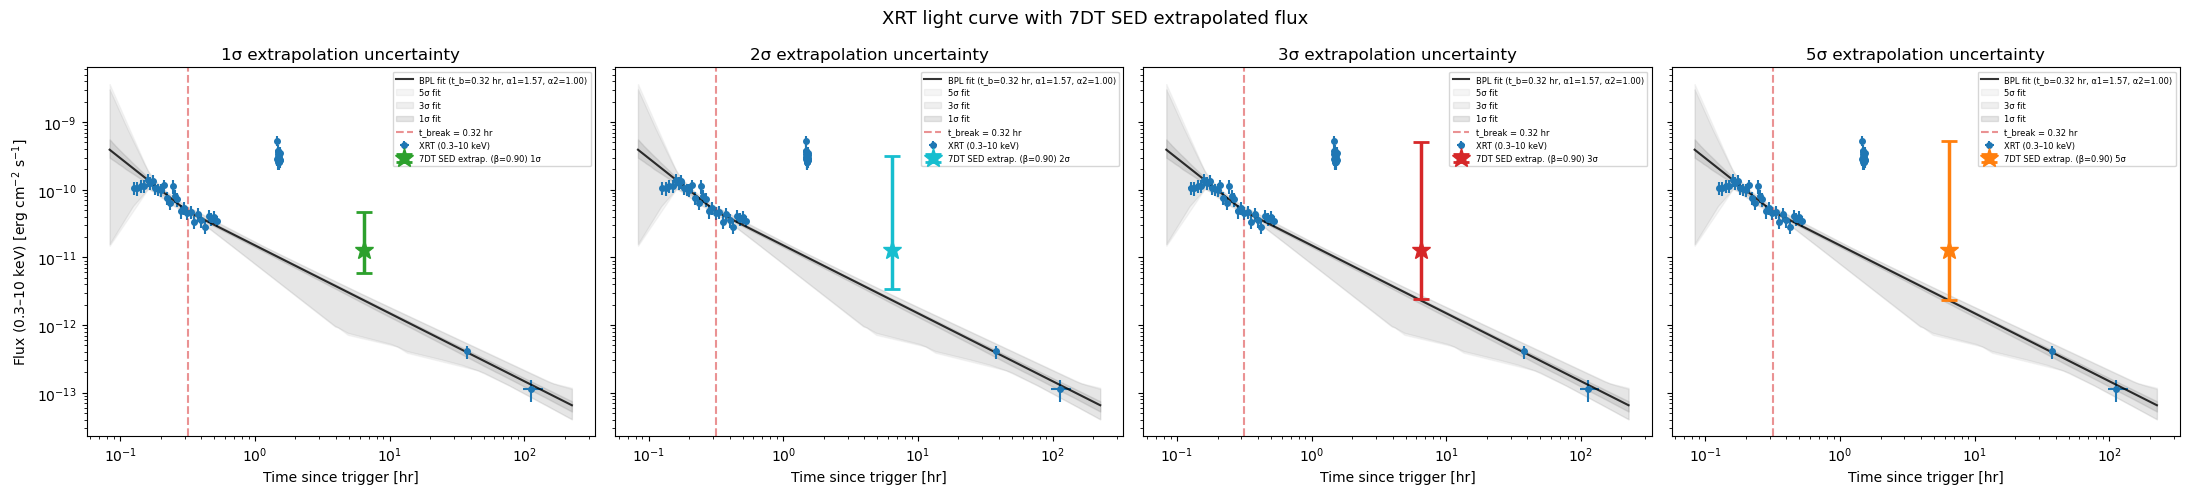

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data
from grb.functions import power_law, broken_power_law

# --- Load SED fit results ---
with open("data/sed_fit_results.pkl", "rb") as f:
    sed = pickle.load(f)

best_params = sed["best_fit_params"]
F0, beta_opt = best_params[0], best_params[1]
t_sdt = sed["sdt_epoch_s"]

# --- Load XRT fit results ---
with open("xrt_fit_results.pkl", "rb") as f:
    xrt = pickle.load(f)["xrt"]

xrt_params = xrt["params"]
xrt_best_fit = xrt["best_fit_params"]
xrt_x = xrt["x_data"]

print(f"XRT fit parameters: {dict(zip(xrt_params, xrt_best_fit))}")

# --- XRT band ---
h_keV_s = 4.135667696e-18
E_lo, E_hi = 0.3, 10.0
nu_xrt_lo = E_lo / h_keV_s
nu_xrt_hi = E_hi / h_keV_s
mJy_to_cgs = 1e-26

df_xrt = read_data("xrt")

# --- Extrapolated integrated 0.3–10 keV flux from 7DT SED ---
def integrated_xrt_flux(F0, beta, nu_lo, nu_hi, x0=1e15):
    if abs(beta - 1.0) > 1e-10:
        integral = F0 * x0**beta * (nu_hi**(1-beta) - nu_lo**(1-beta)) / (1 - beta)
    else:
        integral = F0 * np.log(nu_hi / nu_lo)
    return integral * mJy_to_cgs

samples_sed = sed["weighted_samples"]["points"]
weights_sed = sed["weighted_samples"]["weights"]
idx_sed = np.random.choice(len(samples_sed), size=200, p=weights_sed / weights_sed.sum())
int_flux_samples = np.array([integrated_xrt_flux(s[0], s[1], nu_xrt_lo, nu_xrt_hi) for s in samples_sed[idx_sed]])
int_flux_1s_lo, int_flux_median, int_flux_1s_hi = np.percentile(int_flux_samples, [15.87, 50, 84.13])
int_flux_2s_lo, int_flux_2s_hi = np.percentile(int_flux_samples, [2.275, 97.725])
int_flux_3s_lo, int_flux_3s_hi = np.percentile(int_flux_samples, [0.135, 99.865])
int_flux_5s_lo, int_flux_5s_hi = np.percentile(int_flux_samples, [2.87e-5, 99.99997])

print(f"SDT epoch: {t_sdt:.0f} s ({t_sdt/3600:.1f} hr) after trigger")
print(f"Extrapolated 0.3–10 keV flux (median): {int_flux_median:.4e} erg/cm²/s")
print(f"  1σ: [{int_flux_1s_lo:.4e}, {int_flux_1s_hi:.4e}]")
print(f"  2σ: [{int_flux_2s_lo:.4e}, {int_flux_2s_hi:.4e}]")
print(f"  3σ: [{int_flux_3s_lo:.4e}, {int_flux_3s_hi:.4e}]")
print(f"  5σ: [{int_flux_5s_lo:.4e}, {int_flux_5s_hi:.4e}]")

# --- XRT fit model ---
t_model = np.geomspace(xrt_x.min() * 0.5, xrt_x.max() * 2, 500)
y_model = broken_power_law(t_model, *xrt_best_fit)

samples_xrt = xrt["results"]["weighted_samples"]["points"]
weights_xrt = xrt["results"]["weighted_samples"]["weights"]
idx_xrt = np.random.choice(len(samples_xrt), size=300, p=weights_xrt / weights_xrt.sum())
y_samples = np.array([broken_power_law(t_model, *s) for s in samples_xrt[idx_xrt]])
y_1s_lo, y_1s_hi = np.percentile(y_samples, [15.87, 84.13], axis=0)
y_3s_lo, y_3s_hi = np.percentile(y_samples, [0.135, 99.865], axis=0)
y_5s_lo, y_5s_hi = np.percentile(y_samples, [2.87e-5, 99.99997], axis=0)

# --- XRT data ---
xrt_t    = df_xrt["Time"].values / 3600
xrt_f    = df_xrt["Flux"].values
xrt_t_hi = df_xrt["Time_high"].values / 3600
xrt_t_lo = np.abs(df_xrt["Time_low"].values) / 3600
xrt_f_hi = df_xrt["Flux_high"].values
xrt_f_lo = np.abs(df_xrt["Flux_low"].values)
t_extrap = t_sdt / 3600

bpl_label = f"BPL fit (t_b={xrt_best_fit[1]:.2f} hr, α1={xrt_best_fit[2]:.2f}, α2={xrt_best_fit[3]:.2f})"

def plot_xrt_base(ax):
    ax.errorbar(xrt_t, xrt_f, xerr=[xrt_t_lo, xrt_t_hi], yerr=[xrt_f_lo, xrt_f_hi],
                fmt="o", color="C0", ms=4, label="XRT (0.3–10 keV)")
    ax.plot(t_model, y_model, "k-", alpha=0.8, label=bpl_label)
    ax.fill_between(t_model, y_5s_lo, y_5s_hi, color="gray", alpha=0.08, label="5σ fit")
    ax.fill_between(t_model, y_3s_lo, y_3s_hi, color="gray", alpha=0.12, label="3σ fit")
    ax.fill_between(t_model, y_1s_lo, y_1s_hi, color="gray", alpha=0.2,  label="1σ fit")
    ax.axvline(xrt_best_fit[1], color="C3", ls="--", alpha=0.5,
               label=f"t_break = {xrt_best_fit[1]:.2f} hr")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Time since trigger [hr]")
    ax.set_ylabel(r"Flux (0.3–10 keV) [erg cm$^{-2}$ s$^{-1}$]")

# sigma levels: (lo, hi, color, label)
sigma_configs = [
    (int_flux_1s_lo, int_flux_1s_hi, "C2", "1σ"),
    (int_flux_2s_lo, int_flux_2s_hi, "C9", "2σ"),
    (int_flux_3s_lo, int_flux_3s_hi, "C3", "3σ"),
    (int_flux_5s_lo, int_flux_5s_hi, "C1", "5σ"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for ax, (lo, hi, color, label) in zip(axes, sigma_configs):
    plot_xrt_base(ax)
    ax.errorbar(t_extrap, int_flux_median,
                yerr=[[int_flux_median - lo], [hi - int_flux_median]],
                fmt="*", color=color, ms=14, elinewidth=2.5, capsize=6, capthick=2.0, zorder=5,
                label=f"7DT SED extrap. (β={beta_opt:.2f}) {label}")
    ax.set_title(f"{label} extrapolation uncertainty")
    ax.legend(fontsize=6)

for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle("XRT light curve with 7DT SED extrapolated flux", fontsize=13)
plt.tight_layout()


## 7DT tractor

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from grb.functions import power_law
from grb.io import read_data

# --- Load SED fit results ---
with open("data/sed_fit_results_tractor.pkl", "rb") as f:
    sed_tractor = pickle.load(f)

best_params = sed_tractor["best_fit_params"]
param_names = sed_tractor["param_names"]
F0, beta_opt, Av = best_params[0], best_params[1], best_params[2]
print(f"Loaded SED fit: {dict(zip(param_names, best_params))}")

# --- XRT band frequencies ---
h_keV_s = 4.135667696e-18
E_lo, E_hi, E_ref = 0.3, 10.0, 1.0
nu_xrt_lo = E_lo / h_keV_s
nu_xrt_hi = E_hi / h_keV_s
nu_1keV = E_ref / h_keV_s

mJy_to_cgs = 1e-26

# --- Extrapolated flux density at 1 keV ---
F_nu_1keV_mJy = power_law(nu_1keV, F0, beta_opt, x0=1e15)
print(f"Extrapolated F_ν at 1 keV: {F_nu_1keV_mJy:.4e} mJy = {F_nu_1keV_mJy * mJy_to_cgs:.4e} erg/cm²/s/Hz")

if abs(beta_opt - 1.0) > 1e-10:
    int_flux_mJy_Hz = F0 * (1e15)**beta_opt * (nu_xrt_hi**(1-beta_opt) - nu_xrt_lo**(1-beta_opt)) / (1 - beta_opt)
else:
    int_flux_mJy_Hz = F0 * np.log(nu_xrt_hi / nu_xrt_lo)
int_flux_cgs = int_flux_mJy_Hz * mJy_to_cgs
print(f"Extrapolated 0.3–10 keV integrated flux: {int_flux_cgs:.4e} erg/cm²/s")

# --- Posterior uncertainty ---
samples = sed_tractor["weighted_samples"]["points"]
weights = sed_tractor["weighted_samples"]["weights"]

nu_extrap = np.geomspace(1e14, 3e18, 500)
idx = np.random.choice(len(samples), size=200, p=weights / weights.sum())
flux_samples_mJy = np.array([power_law(nu_extrap, s[0], s[1], x0=1e15) for s in samples[idx]])
flux_lo_mJy, flux_hi_mJy = np.percentile(flux_samples_mJy, [2.87e-5, 99.99997], axis=0)

F_1keV_samples = np.array([power_law(nu_1keV, s[0], s[1], x0=1e15) for s in samples[idx]])
F_1keV_lo, F_1keV_median, F_1keV_hi = np.percentile(F_1keV_samples, [2.87e-5, 50, 99.99997])
print(f"F_ν(1 keV) median: {F_1keV_median:.4e} mJy, 5σ range: [{F_1keV_lo:.4e}, {F_1keV_hi:.4e}] mJy")

flux_extrap_mJy = power_law(nu_extrap, F0, beta_opt, x0=1e15)

# --- Load XRT data and convert integrated flux → F_ν at 1 keV ---
df_xrt = read_data("xrt")
xrt_epoch_s = df_xrt["Time"].values

def fint_to_fnu_mJy(F_int, beta, nu_0, nu_lo, nu_hi):
    if abs(beta - 1.0) > 1e-10:
        factor = (1 - beta) / (nu_0**beta * (nu_hi**(1-beta) - nu_lo**(1-beta)))
    else:
        factor = 1.0 / (nu_0 * np.log(nu_hi / nu_lo))
    return F_int * factor / mJy_to_cgs

xrt_fnu    = fint_to_fnu_mJy(df_xrt["Flux"].values,              beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)
xrt_fnu_hi = fint_to_fnu_mJy(df_xrt["Flux_high"].values,        beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)
xrt_fnu_lo = fint_to_fnu_mJy(np.abs(df_xrt["Flux_low"].values), beta_opt, nu_1keV, nu_xrt_lo, nu_xrt_hi)

norm = plt.Normalize(np.log10(xrt_epoch_s.min()), np.log10(xrt_epoch_s.max()))
cmap = plt.cm.plasma

# --- Plot 1: mJy scale ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.errorbar(sed_tractor["x_data"], sed_tractor["y_data"], yerr=sed_tractor["y_data_error"], xerr=sed_tractor["x_data_error"],
             ls="", marker="o", color="C0", zorder=5, label="7DT tractor (optical)")
ax1.plot(nu_extrap, flux_extrap_mJy, "k--", alpha=0.7, label=f"Intrinsic PL (β = {beta_opt:.2f})")
ax1.fill_between(nu_extrap, flux_lo_mJy, flux_hi_mJy, color="gray", alpha=0.2, label="5σ posterior")
ax1.errorbar(nu_1keV, F_1keV_median, yerr=[[F_1keV_median - F_1keV_lo], [F_1keV_hi - F_1keV_median]],
             fmt="*", color="C3", ms=12, zorder=6, label="Extrapolated @ 1 keV (5σ)")
sc1 = ax1.scatter([nu_1keV]*len(xrt_fnu), xrt_fnu,
                  c=np.log10(xrt_epoch_s), cmap=cmap, norm=norm,
                  s=30, zorder=5, marker="s", alpha=0.8, label="XRT data (@ 1 keV)")
ax1.errorbar([nu_1keV]*len(xrt_fnu), xrt_fnu,
             yerr=[xrt_fnu_lo, xrt_fnu_hi],
             fmt="none", ecolor="gray", elinewidth=0.8, alpha=0.5, zorder=4)
ax1.axvspan(nu_xrt_lo, nu_xrt_hi, alpha=0.05, color="C3", label="0.3–10 keV band")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("Frequency [Hz]"); ax1.set_ylabel("Flux density [mJy]")
ax1.set_title("Flux density [mJy]")
ax1.legend(fontsize=7); ax1.set_xlim(1e14, 5e18)
plt.colorbar(sc1, ax=ax1, label="log₁₀(t − T₀) [s]")

# --- Plot 2: νF_ν scale ---
nuFnu_extrap = nu_extrap * flux_extrap_mJy * mJy_to_cgs
nuFnu_lo     = nu_extrap * flux_lo_mJy * mJy_to_cgs
nuFnu_hi     = nu_extrap * flux_hi_mJy * mJy_to_cgs

nuFnu_data      = sed_tractor["x_data"] * sed_tractor["y_data"] * mJy_to_cgs
nuFnu_data_err  = sed_tractor["x_data"] * sed_tractor["y_data_error"] * mJy_to_cgs
nuFnu_data_xerr = sed_tractor["x_data_error"]

nuFnu_1keV_median = nu_1keV * F_1keV_median * mJy_to_cgs
nuFnu_1keV_lo     = nu_1keV * F_1keV_lo * mJy_to_cgs
nuFnu_1keV_hi     = nu_1keV * F_1keV_hi * mJy_to_cgs

nuFnu_xrt    = nu_1keV * xrt_fnu    * mJy_to_cgs
nuFnu_xrt_hi = nu_1keV * xrt_fnu_hi * mJy_to_cgs
nuFnu_xrt_lo = nu_1keV * xrt_fnu_lo * mJy_to_cgs

ax2.errorbar(sed_tractor["x_data"], nuFnu_data, yerr=nuFnu_data_err, xerr=nuFnu_data_xerr,
             ls="", marker="o", color="C0", zorder=5, label="7DT tractor (optical)")
ax2.plot(nu_extrap, nuFnu_extrap, "k--", alpha=0.7, label=f"Intrinsic PL (β = {beta_opt:.2f})")
ax2.fill_between(nu_extrap, nuFnu_lo, nuFnu_hi, color="gray", alpha=0.2, label="5σ posterior")
ax2.errorbar(nu_1keV, nuFnu_1keV_median,
             yerr=[[nuFnu_1keV_median - nuFnu_1keV_lo], [nuFnu_1keV_hi - nuFnu_1keV_median]],
             fmt="*", color="C3", ms=12, zorder=6, label="Extrapolated @ 1 keV (5σ)")
sc2 = ax2.scatter([nu_1keV]*len(nuFnu_xrt), nuFnu_xrt,
                  c=np.log10(xrt_epoch_s), cmap=cmap, norm=norm,
                  s=30, zorder=5, marker="s", alpha=0.8, label="XRT data (@ 1 keV)")
ax2.errorbar([nu_1keV]*len(nuFnu_xrt), nuFnu_xrt,
             yerr=[nuFnu_xrt_lo, nuFnu_xrt_hi],
             fmt="none", ecolor="gray", elinewidth=0.8, alpha=0.5, zorder=4)
ax2.axvspan(nu_xrt_lo, nu_xrt_hi, alpha=0.05, color="C3", label="0.3–10 keV band")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
ax2.set_title(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
ax2.legend(fontsize=7); ax2.set_xlim(1e14, 5e18)
plt.colorbar(sc2, ax=ax2, label="log₁₀(t − T₀) [s]")

fig.suptitle("7DT Tractor SED extrapolation to XRT band", fontsize=13)
plt.tight_layout()


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from grb.io import read_data
from grb.functions import broken_power_law

# --- Load SED fit results ---
with open("data/sed_fit_results_tractor.pkl", "rb") as f:
    sed_tractor = pickle.load(f)

best_params = sed_tractor["best_fit_params"]
F0, beta_opt = best_params[0], best_params[1]
t_sdt = sed_tractor["sdt_epoch_s"]

# --- Load XRT fit results ---
with open("xrt_fit_results.pkl", "rb") as f:
    xrt = pickle.load(f)["xrt"]

xrt_params = xrt["params"]
xrt_best_fit = xrt["best_fit_params"]
xrt_x = xrt["x_data"]

print(f"XRT fit parameters: {dict(zip(xrt_params, xrt_best_fit))}")

# --- XRT band ---
h_keV_s = 4.135667696e-18
E_lo, E_hi = 0.3, 10.0
nu_xrt_lo = E_lo / h_keV_s
nu_xrt_hi = E_hi / h_keV_s
mJy_to_cgs = 1e-26

df_xrt = read_data("xrt")

# --- Extrapolated integrated 0.3–10 keV flux from 7DT tractor SED ---
def integrated_xrt_flux(F0, beta, nu_lo, nu_hi, x0=1e15):
    if abs(beta - 1.0) > 1e-10:
        integral = F0 * x0**beta * (nu_hi**(1-beta) - nu_lo**(1-beta)) / (1 - beta)
    else:
        integral = F0 * np.log(nu_hi / nu_lo)
    return integral * mJy_to_cgs

samples_sed = sed_tractor["weighted_samples"]["points"]
weights_sed = sed_tractor["weighted_samples"]["weights"]
idx_sed = np.random.choice(len(samples_sed), size=200, p=weights_sed / weights_sed.sum())
int_flux_samples = np.array([integrated_xrt_flux(s[0], s[1], nu_xrt_lo, nu_xrt_hi) for s in samples_sed[idx_sed]])
int_flux_1s_lo, int_flux_median, int_flux_1s_hi = np.percentile(int_flux_samples, [15.87, 50, 84.13])
int_flux_2s_lo, int_flux_2s_hi = np.percentile(int_flux_samples, [2.275, 97.725])
int_flux_3s_lo, int_flux_3s_hi = np.percentile(int_flux_samples, [0.135, 99.865])
int_flux_5s_lo, int_flux_5s_hi = np.percentile(int_flux_samples, [2.87e-5, 99.99997])

print(f"SDT epoch: {t_sdt:.0f} s ({t_sdt/3600:.1f} hr) after trigger")
print(f"Extrapolated 0.3–10 keV flux (median): {int_flux_median:.4e} erg/cm²/s")
print(f"  1σ: [{int_flux_1s_lo:.4e}, {int_flux_1s_hi:.4e}]")
print(f"  2σ: [{int_flux_2s_lo:.4e}, {int_flux_2s_hi:.4e}]")
print(f"  3σ: [{int_flux_3s_lo:.4e}, {int_flux_3s_hi:.4e}]")
print(f"  5σ: [{int_flux_5s_lo:.4e}, {int_flux_5s_hi:.4e}]")

# --- XRT fit model ---
t_model = np.geomspace(xrt_x.min() * 0.5, xrt_x.max() * 2, 500)
y_model = broken_power_law(t_model, *xrt_best_fit)

samples_xrt = xrt["results"]["weighted_samples"]["points"]
weights_xrt = xrt["results"]["weighted_samples"]["weights"]
idx_xrt = np.random.choice(len(samples_xrt), size=300, p=weights_xrt / weights_xrt.sum())
y_samples = np.array([broken_power_law(t_model, *s) for s in samples_xrt[idx_xrt]])
y_1s_lo, y_1s_hi = np.percentile(y_samples, [15.87, 84.13], axis=0)
y_3s_lo, y_3s_hi = np.percentile(y_samples, [0.135, 99.865], axis=0)
y_5s_lo, y_5s_hi = np.percentile(y_samples, [2.87e-5, 99.99997], axis=0)

# --- XRT data ---
xrt_t    = df_xrt["Time"].values / 3600
xrt_f    = df_xrt["Flux"].values
xrt_t_hi = df_xrt["Time_high"].values / 3600
xrt_t_lo = np.abs(df_xrt["Time_low"].values) / 3600
xrt_f_hi = df_xrt["Flux_high"].values
xrt_f_lo = np.abs(df_xrt["Flux_low"].values)
t_extrap = t_sdt / 3600

bpl_label = f"BPL fit (t_b={xrt_best_fit[1]:.2f} hr, α1={xrt_best_fit[2]:.2f}, α2={xrt_best_fit[3]:.2f})"

def plot_xrt_base(ax):
    ax.errorbar(xrt_t, xrt_f, xerr=[xrt_t_lo, xrt_t_hi], yerr=[xrt_f_lo, xrt_f_hi],
                fmt="o", color="C0", ms=4, label="XRT (0.3–10 keV)")
    ax.plot(t_model, y_model, "k-", alpha=0.8, label=bpl_label)
    ax.fill_between(t_model, y_5s_lo, y_5s_hi, color="gray", alpha=0.08, label="5σ fit")
    ax.fill_between(t_model, y_3s_lo, y_3s_hi, color="gray", alpha=0.12, label="3σ fit")
    ax.fill_between(t_model, y_1s_lo, y_1s_hi, color="gray", alpha=0.2,  label="1σ fit")
    ax.axvline(xrt_best_fit[1], color="C3", ls="--", alpha=0.5,
               label=f"t_break = {xrt_best_fit[1]:.2f} hr")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Time since trigger [hr]")
    ax.set_ylabel(r"Flux (0.3–10 keV) [erg cm$^{-2}$ s$^{-1}$]")

# sigma levels: (lo, hi, color, label)
sigma_configs = [
    (int_flux_1s_lo, int_flux_1s_hi, "C2", "1σ"),
    (int_flux_2s_lo, int_flux_2s_hi, "C9", "2σ"),
    (int_flux_3s_lo, int_flux_3s_hi, "C3", "3σ"),
    (int_flux_5s_lo, int_flux_5s_hi, "C1", "5σ"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)

for ax, (lo, hi, color, label) in zip(axes, sigma_configs):
    plot_xrt_base(ax)
    ax.errorbar(t_extrap, int_flux_median,
                yerr=[[int_flux_median - lo], [hi - int_flux_median]],
                fmt="*", color=color, ms=14, elinewidth=2.5, capsize=6, capthick=2.0, zorder=5,
                label=f"7DT tractor SED extrap. (β={beta_opt:.2f}) {label}")
    ax.set_title(f"{label} extrapolation uncertainty")
    ax.legend(fontsize=6)

for ax in axes[1:]:
    ax.set_ylabel("")

fig.suptitle("XRT light curve with 7DT tractor SED extrapolated flux", fontsize=13)
plt.tight_layout()
